# Center-out

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*Overriding environment.*")

import mujoco
import myosuite
from mujoco_pipeline.fetch_models import fetch_ms_human_700

fetch_ms_human_700()
print(mujoco.__version__)


MyoSuite:> Registering Myo Envs
MS-Human-700 already present at /Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/third_party/mujoco_menagerie/ms_human_700/MS-Human-700-Manipulation.xml
3.14.0


## MuJoCo

In [2]:
from mujoco_pipeline.pipeline import run

run("mujoco_pipeline/configs/center_out.yaml")



=== myosuite ===


MyoSuite myoarm.xml, the arm used by myoArmReachFixed-v0. It was converted from the MoBL OpenSim upper extremity.
  - End effector is the index fingertip site IFtip, which is the site MyoSuite's arm-reach task tracks. OpenSim tracks a Handle marker in the palm, so the Cartesian point is not identical.
  - Muscle names match the OpenSim 25-muscle list exactly.
  - Reported length is MuJoCo actuator length (musculotendon), not OpenSim equilibrated fiber length.
  Rest hand, shoulder-centered cm: [ -2.78 -47.88 -18.7 ]
  Rest actuator length (mm): 38.5–385.0


  0_right          IK mean 0.004 cm, max 0.049 cm, rates 0.0–30.1 Hz


  45_fwd_right     IK mean 0.004 cm, max 0.050 cm, rates 0.0–42.2 Hz


  90_forward       IK mean 0.004 cm, max 0.050 cm, rates 0.0–36.5 Hz


...

  270_backward     IK mean 0.008 cm, max 0.049 cm, rates 0.0–24.5 Hz


  315_back_right   IK mean 0.004 cm, max 0.050 cm, rates 0.0–20.6 Hz


  Wrote format example example_reaches_not_for_training.hdf5 (8 trials)



Outputs: /Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/outputs_mujoco/mujoco_center_out


{'experiment': 'mujoco_center_out',
 'output_dir': '/Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/outputs_mujoco/mujoco_center_out',
 'comparison_figure': '/Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/outputs_mujoco/mujoco_center_out/comparison_forward_reach.png',
 'spindle_config': '/Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/extract_data/configs/train_test_data_spindles_extended.yaml',
 'backends': {'myosuite': {'source': '/Users/macbookair2026/Documents/motor-metamers/MotorMetamersuPNC/.venv-mujoco/lib/python3.14/site-packages/myosuite/simhive/myo_sim/arm/myoarm.xml',
   'notes': ["End effector is the index fingertip site IFtip, which is the site MyoSuite's arm-reach task tracks. OpenSim tracks a Handle marker in the palm, so the Cartesian point is not identical.",
    'Muscle names match the OpenSim 25-muscle list exactly.',
    'Reported length is MuJoCo actuator length (musculotendon), not OpenSim equilibrated fiber leng

## OpenSim

In [3]:
import subprocess
from pathlib import Path

import numpy as np

from mujoco_pipeline.spindles import firing_rates, spindle_coefficients

root = Path(".").resolve()
muscle_dir = root / "outputs" / "center_out" / "muscles"
if not (muscle_dir / "90_forward.npz").is_file():
    subprocess.run(
        [root / ".venv-opensim" / "bin" / "python", "run_pipeline.py", "--through", "muscle-lengths"],
        check=True,
    )

config, coefficients, sampled, muscles = spindle_coefficients(0, 5)
optimal = np.asarray(config["optimal_lengths"], dtype=np.float32)
spindle_dir = root / "outputs" / "center_out" / "spindles"
spindle_dir.mkdir(parents=True, exist_ok=True)
for path in sorted(muscle_dir.glob("*.npz")):
    data = np.load(path)
    rates, _, _ = firing_rates(
        data["fiber_lengths"], data["times"], optimal,
        config, coefficients, sampled, muscles,
    )
    np.savez(
        spindle_dir / path.name,
        times=data["times"],
        firing_rates=rates,
        fiber_lengths=data["fiber_lengths"],
        optimal_lengths_mm=optimal,
    )
print(len(list(spindle_dir.glob("*.npz"))), "reaches")


8 reaches


## Firing rates

Text(0.5, 0.98, 'BIClong, eight directions')

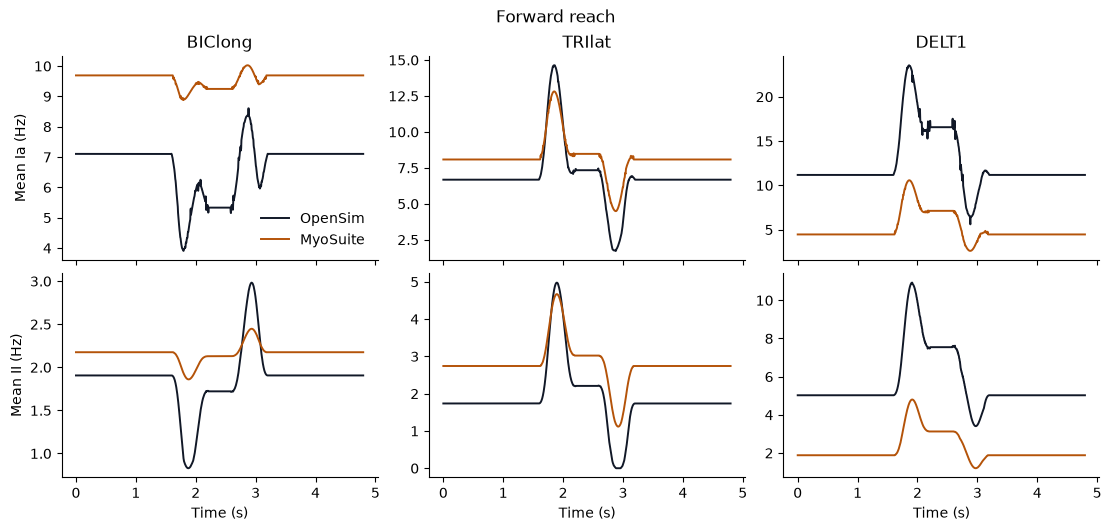

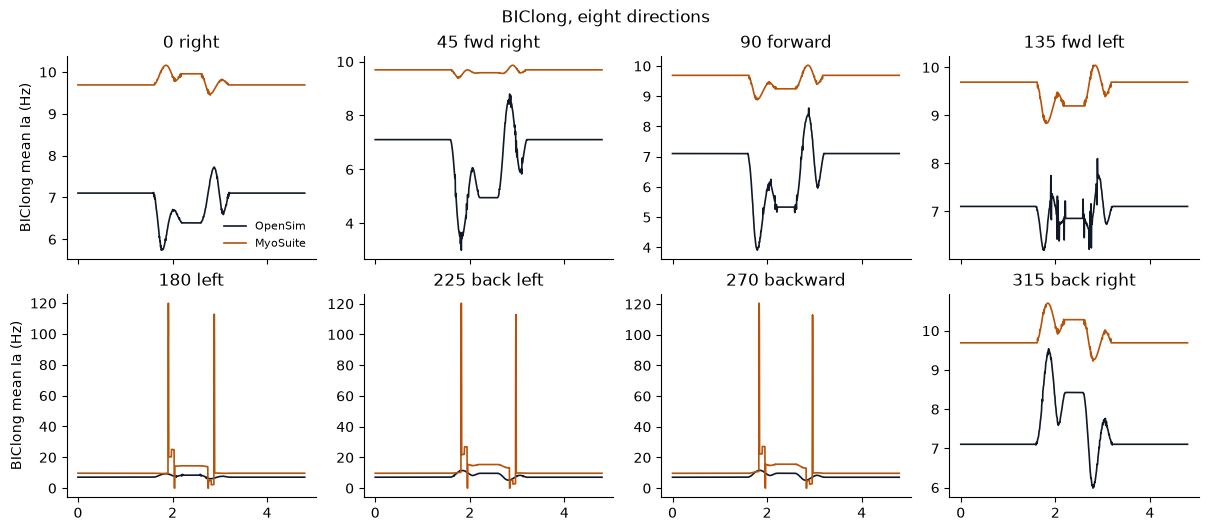

In [4]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.muscle_names import MUSCLE_NAMES

PLOT = ["BIClong", "TRIlat", "DELT1"]
DIRECTIONS = [
    "0_right", "45_fwd_right", "90_forward", "135_fwd_left",
    "180_left", "225_back_left", "270_backward", "315_back_right",
]
COLORS = {"OpenSim": "#111827", "MyoSuite": "#b45309"}


def load_pair(direction):
    opensim = np.load(Path("outputs/center_out/spindles") / f"{direction}.npz")
    myosuite = np.load(
        Path("outputs_mujoco/mujoco_center_out/myosuite/spindles") / f"{direction}.npz"
    )
    return opensim, myosuite


def mean_rate(bundle, muscle, afferent):
    index = MUSCLE_NAMES.index(muscle)
    start = 0 if afferent == "Ia" else 5
    return bundle["firing_rates"][0, start:start + 5, index].mean(axis=0)


fig, axes = plt.subplots(2, 3, figsize=(11, 5.2), sharex=True, layout="constrained")
opensim, myosuite = load_pair("90_forward")
for column, muscle in enumerate(PLOT):
    for name, bundle in (("OpenSim", opensim), ("MyoSuite", myosuite)):
        axes[0, column].plot(bundle["times"], mean_rate(bundle, muscle, "Ia"), color=COLORS[name], label=name, lw=1.4)
        axes[1, column].plot(bundle["times"], mean_rate(bundle, muscle, "II"), color=COLORS[name], lw=1.4)
    axes[0, column].set_title(muscle)
    axes[1, column].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Mean Ia (Hz)")
axes[1, 0].set_ylabel("Mean II (Hz)")
axes[0, 0].legend(frameon=False)
for axis in axes.flat:
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Forward reach")

fig, axes = plt.subplots(2, 4, figsize=(12, 5.2), sharex=True, layout="constrained")
for axis, direction in zip(axes.flat, DIRECTIONS):
    opensim, myosuite = load_pair(direction)
    for name, bundle in (("OpenSim", opensim), ("MyoSuite", myosuite)):
        axis.plot(bundle["times"], mean_rate(bundle, "BIClong", "Ia"), color=COLORS[name], label=name, lw=1.2)
    axis.set_title(direction.replace("_", " "))
    axis.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylabel("BIClong mean Ia (Hz)")
axes[1, 0].set_ylabel("BIClong mean Ia (Hz)")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("BIClong, eight directions")
